In [ ]:
# IMPORTS
import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import load_model

pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 99999
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ULTILITY FUNCTION
def create_sequence(mtx, timestep:int):
  x = []
  y = []
  window = timestep + 1

  for i in range(mtx.shape[0] - window + 1):
    sample = mtx[i: i+window]
    x.append(sample[:-1])
    y.append(sample[-1])

  return np.array(x), np.array(y)

In [ ]:
# GLOBAL PARAMETERS
TARGET = 'unemploy'
TRAIN_RATIO = 0.85  # test starts in 2008
SCALER = StandardScaler()  # to prevent sartuation
TIMESTEPS = 12
BATCH_SIZE = 2
leaky_relu = LeakyReLU(negative_slope=0.1)  # y = max(ax, x)


/tmp/ipykernel_2037/293730425.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  econ = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "utkarshx27/us-economic-time-series", "economics.csv")


Using Colab cache for faster access to the 'us-economic-time-series' dataset.


,unemploy
date,
1967-07-01,2944
1967-08-01,2945
1967-09-01,2958
1967-10-01,3143
1967-11-01,3066


<class 'pandas.core.series.Series'>
DatetimeIndex: 574 entries, 1967-07-01 to 2015-04-01
Series name: unemploy
Non-Null Count  Dtype
--------------  -----
574 non-null    int64
dtypes: int64(1)
memory usage: 9.0 KB


None

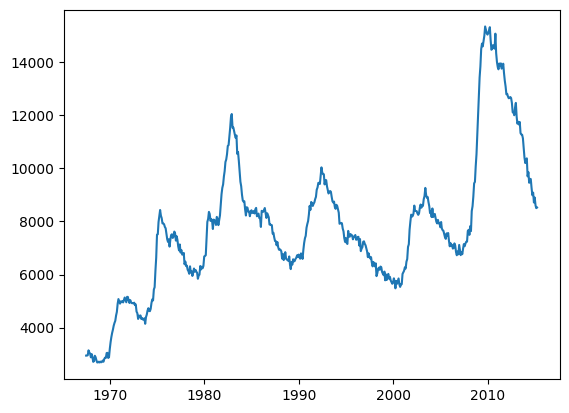

In [ ]:
# Load dataset
econ = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "utkarshx27/us-economic-time-series", "economics.csv")

econ = econ.drop(columns="Unnamed: 0")
econ['date'] = pd.to_datetime(econ['date'], format='mixed')
econ['pop'] = econ['pop'].astype(int)
econ['unemploy'] = econ['unemploy'].astype(int)
econ = econ.set_index('date')

target = econ[TARGET]

display(target.head())
display(target.info())
plt.plot(target)

In [ ]:
# Train test split
train_size = int(target.shape[0]*TRAIN_RATIO)

# Rolling window drops first n timesteps in data in test set, we must avoid this.
# So the last window in train set is used to predict the first value in test set.
test_size = train_size - TIMESTEPS
# Just a trick, still maintain 85/15 ratio, preventing data leak.

train_set, test_set = target[:train_size].values.reshape(-1,1), target[test_size:].values.reshape(-1,1)
test_index = target[test_size + TIMESTEPS:].index
train_index = target[:train_size].index

print(train_set.shape)
print(test_set.shape)
print(test_index)

(487, 1)
(99, 1)
DatetimeIndex(['2008-02-01', '2008-03-01', '2008-04-01', '2008-05-01',
               '2008-06-01', '2008-07-01', '2008-08-01', '2008-09-01',
               '2008-10-01', '2008-11-01', '2008-12-01', '2009-01-01',
               '2009-02-01', '2009-03-01', '2009-04-01', '2009-05-01',
               '2009-06-01', '2009-07-01', '2009-08-01', '2009-09-01',
               '2009-10-01', '2009-11-01', '2009-12-01', '2010-01-01',
               '2010-02-01', '2010-03-01', '2010-04-01', '2010-05-01',
               '2010-06-01', '2010-07-01', '2010-08-01', '2010-09-01',
               '2010-10-01', '2010-11-01', '2010-12-01', '2011-01-01',
               '2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01',
               '2011-06-01', '2011-07-01', '2011-08-01', '2011-09-01',
               '2011-10-01', '2011-11-01', '2011-12-01', '2012-01-01',
               '2012-02-01', '2012-03-01', '2012-04-01', '2012-05-01',
               '2012-06-01', '2012-07-01', '2012-08-01', '20

In [ ]:
# Standard Scaler
scaler = SCALER.fit(train_set)

scaled_train = scaler.transform(train_set)
scaled_test = scaler.transform(test_set)

print(scaled_train[:10])
print(scaled_train.shape)
print(scaled_test.shape)

[[-2.20454119]
 [-2.20399786]
 [-2.19693457]
 [-2.09641856]
 [-2.13825495]
 [-2.16433479]
 [-2.24040096]
 [-2.17357139]
 [-2.24094429]
 [-2.3322237 ]]
(487, 1)
(99, 1)


In [ ]:
# Tensorization

X_train, y_train = create_sequence(scaled_train, TIMESTEPS)
X_test, y_test = create_sequence(scaled_test, TIMESTEPS)

print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(475, 12, 1)
(475, 1)
(87, 1)


In [ ]:
tf.keras.backend.clear_session()

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32, activation=leaky_relu, kernel_initializer='he_normal', seed=26, return_sequences=True),
    Dropout(rate=0.1, seed=26),
    LSTM(16, activation=leaky_relu, kernel_initializer='he_normal', seed=26, return_sequences=False),
    Dense(1, activation=leaky_relu, kernel_initializer='he_normal')
])

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001, ema_momentum=0.9), loss='mae')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
call_back = EarlyStopping(patience=10, restore_best_weights=True, start_from_epoch=0)

model_fit = model.fit(
    x=X_train, y=y_train,
    batch_size=BATCH_SIZE,
    validation_split=0.13,
    verbose=1,
    callbacks=[call_back],
    shuffle = False,
    epochs=25
)

model.save("onestep_lstm_" + TARGET + ".keras")

Epoch 1/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.4892 - val_loss: 0.1460
Epoch 2/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3811 - val_loss: 0.0915
Epoch 3/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2505 - val_loss: 0.0995
Epoch 4/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2193 - val_loss: 0.1311
Epoch 5/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2020 - val_loss: 0.1125
Epoch 6/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1714 - val_loss: 0.1078
Epoch 7/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1761 - val_loss: 0.1189
Epoch 8/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1595 - val_loss: 0.1063
Epoch 9/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1409 - val_loss: 0.0942
Epoch 10/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1462 - val_loss: 0.0866
Epoch 11/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1224 - val_loss: 0.0831
Epoch 12/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

In [ ]:
model = load_model("onestep_lstm_" + TARGET + ".keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,517 (87.96 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,012 (58.64 KB)

In [ ]:
pred = model.predict(X_test)

print(pred.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
(87, 1)


In [ ]:
pred_org = scaler.inverse_transform(pred).flatten()
y_train_org = scaler.inverse_transform(y_train).flatten()
y_test_org = scaler.inverse_transform(y_test).flatten()

model_mse = root_mean_squared_error(pred_org, y_test_org)
model_mae = mean_absolute_error(pred_org, y_test_org)
model_mape = mean_absolute_percentage_error(pred_org, y_test_org)

print(model_mse)
print(model_mae)
print(model_mape)

614.6319487136947
530.6970467403017
0.044267491016731414


In [ ]:
train_line = target[400:train_size]
test_line = pd.Series(index=test_index, data=y_test_org)
pred_line = pd.Series(index=test_index, data=pred_org)

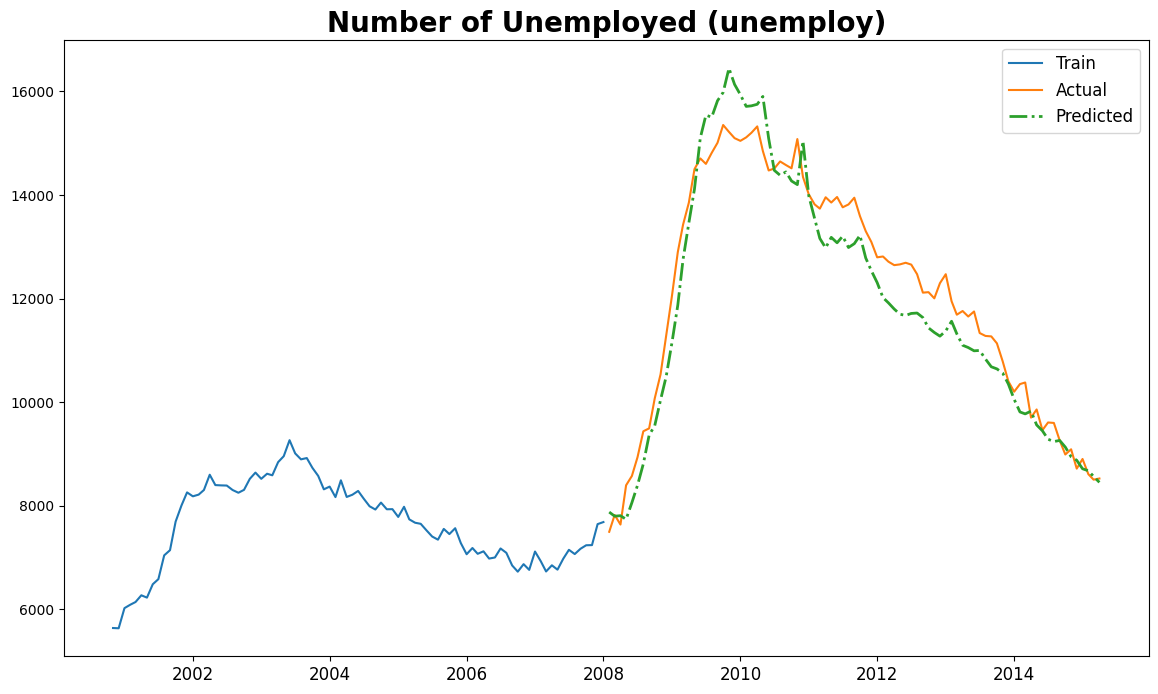

In [ ]:
plt.figure(figsize=(14,8))
plt.plot(train_line, label="Train")
plt.plot(test_line, label="Actual")
plt.plot(pred_line, label="Predicted", lw=2, ls='-.')
plt.title("Number of Unemployed (unemploy)", fontsize=20, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()